In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/Position_Salaries.csv')

In [18]:
df.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [19]:
df.shape

(10, 3)

In [20]:
df.describe()

,Level,Salary
count,10.00000,10.000000
mean,5.50000,249500.000000
std,3.02765,299373.883668
min,1.00000,45000.000000
25%,3.25000,65000.000000
50%,5.50000,130000.000000
75%,7.75000,275000.000000
max,10.00000,1000000.000000


In [21]:
df.isnull().sum()

Position    0
Level       0
Salary      0
dtype: int64

In [22]:
df.duplicated().sum()

np.int64(0)

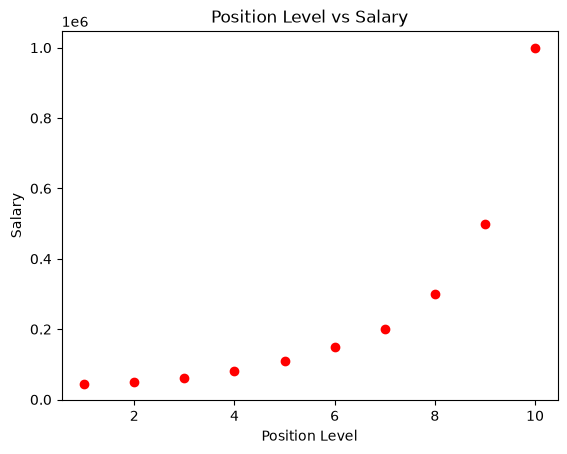

In [23]:
plt.scatter(df['Level'], df['Salary'], color='red')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.title('Position Level vs Salary')
plt.show()

In [24]:
df[['Level','Salary']].corr()

,Level,Salary
Level,1.000000,0.817949
Salary,0.817949,1.000000


In [25]:
df['Position'].unique()

<ArrowStringArray>
[ 'Business Analyst', 'Junior Consultant', 'Senior Consultant',
           'Manager',   'Country Manager',    'Region Manager',
           'Partner',    'Senior Partner',           'C-level',
               'CEO']
Length: 10, dtype: str

In [26]:
X = df[['Level']]
y = df['Salary']

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
print("Train levels:", X_train.values.ravel())
print("Test levels:", X_test.values.ravel())

(8, 1) (2, 1) (8,) (2,)
Train levels: [ 6  1  8  3 10  5  4  7]
Test levels: [9 2]


In [28]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=4)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print(X_train_poly.shape)
print(X_train_poly[:3])

(8, 5)
[[1.000e+00 6.000e+00 3.600e+01 2.160e+02 1.296e+03]
 [1.000e+00 1.000e+00 1.000e+00 1.000e+00 1.000e+00]
 [1.000e+00 8.000e+00 6.400e+01 5.120e+02 4.096e+03]]


In [29]:
from sklearn.linear_model import LinearRegression

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 0. ,-188149.59, 84711.19, -13818.8 , 806.58]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.624e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](5,)","[9027.61, 115.37, 4.16, 0.2 , 0. ]"


In [30]:
print("Coefficients:", poly_model.coef_)
print("Intercept:", poly_model.intercept_)

Coefficients: [      0.         -188149.59289      84711.19454691  -13818.79834549
     806.57593376]
Intercept: 162437.0155040177


In [31]:
y_pred = poly_model.predict(X_test_poly)
print("Predicted:", y_pred)
print("Actual:", y_test.values)

Predicted: [548738.14530749  27337.43608784]
Actual: [500000  50000]


c:\Users\sivag\git-projects\ml-ai-genai-agentic-practice\slr-uk-house-price\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


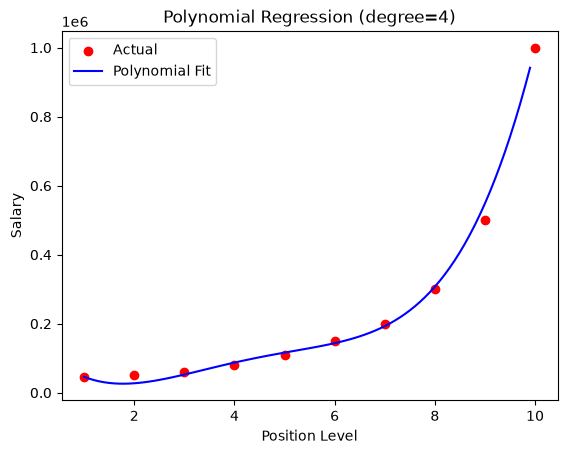

In [33]:
#Visualize the fit
# Create a smooth range of Level values for a clean curve
X_grid = np.arange(X.values.min(), X.values.max(), 0.1).reshape(-1, 1)
X_grid_poly = poly.transform(X_grid)

plt.scatter(X['Level'], y, color='red', label='Actual')
plt.plot(X_grid, poly_model.predict(X_grid_poly), color='blue', label='Polynomial Fit')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.title('Polynomial Regression (degree=4)')
plt.legend()
plt.show()


In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 35700.35460982748
MSE: 1444499305.5435529
RMSE: 38006.56924195543
R² Score: 0.9714666803843249


c:\Users\sivag\git-projects\ml-ai-genai-agentic-practice\slr-uk-house-price\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\sivag\git-projects\ml-ai-genai-agentic-practice\slr-uk-house-price\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


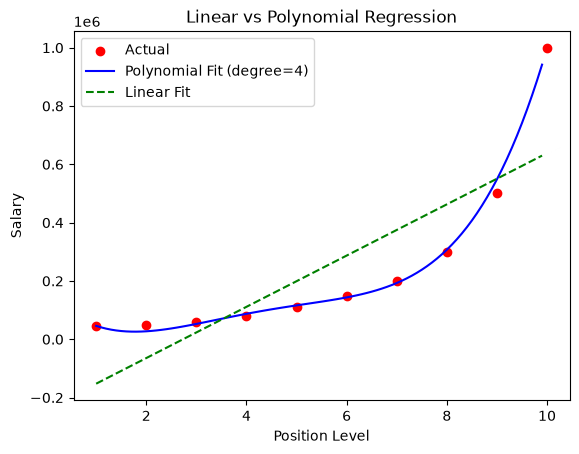

In [35]:
from sklearn.linear_model import LinearRegression

# Plain linear fit for comparison
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

plt.scatter(X['Level'], y, color='red', label='Actual')
plt.plot(X_grid, poly_model.predict(poly.transform(X_grid)), color='blue', label='Polynomial Fit (degree=4)')
plt.plot(X_grid, linear_model.predict(X_grid), color='green', linestyle='--', label='Linear Fit')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.title('Linear vs Polynomial Regression')
plt.legend()
plt.show()

In [36]:
import pickle

with open('../src/poly_model.pkl', 'wb') as file:
    pickle.dump(poly_model, file)

with open('../src/poly_transformer.pkl', 'wb') as file:
    pickle.dump(poly, file)